In [17]:
!pip install pyarrow

   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   - -------------------------------------- 0.8/28.1 MB 16.4 MB/s eta 0:00:02
   ------- -------------------------------- 5.5/28.1 MB 21.0 MB/s eta 0:00:02
   -------------- ------------------------- 10.5/28.1 MB 23.3 MB/s eta 0:00:01
   ------------------------ --------------- 17.6/28.1 MB 25.7 MB/s eta 0:00:01
   ----------------------------------- ---- 24.9/28.1 MB 28.2 MB/s eta 0:00:01
   ---------------------------------------- 28.1/28.1 MB 27.4 MB/s  0:00:01


In [3]:
import os
os.environ["POLYGON_API_KEY"] = "RQ5xXMXAaktwTevFdi26WlsBC6XG5qUO"

In [4]:
# Cell 1: Imports and Setup
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add the src directory to path
sys.path.insert(0, r'C:\Users\phemm\orb_lab\src')

# Import data collector
from data_collector import PolygonDataCollector

# Import the backtester
from orb_backtester import ORBBacktester, ORBConfig, run_backtest, calculate_metrics

print("✓ All imports successful")

✓ All imports successful


In [5]:
# Cell 2: Fetch Data
collector = PolygonDataCollector()

# Fetch 60 days of 1-minute data for NVDA
symbol = 'NVDA'
df = collector.fetch_bars(symbol, days_back=60, bar_size=1)

print(f"\n✓ Loaded {len(df)} bars for {symbol}")
print(f"  Date range: {df.index[0]} to {df.index[-1]}")
print(f"  Columns: {list(df.columns)}")

[DataCollector] Using cache: C:\Users\phemm\orb_lab\data\cache
📊 Fetching NVDA (1-min bars, 60 days)...
  ✓ Fetched 16622 bars, cached for next time

✓ Loaded 16622 bars for NVDA
  Date range: 2025-10-27 09:30:00-04:00 to 2025-12-26 16:00:00-05:00
  Columns: ['open', 'high', 'low', 'close', 'volume', 'vwap', 'trades']


In [ ]:
# Cell 3: Quick Data Check
print("First few bars:")
df.head()

In [6]:
# Cell 4: Create Default Config
# This uses all the default values matching your Pine script
config = ORBConfig()

print("✓ Created default ORBConfig")
print(f"  ORB minutes: {config.orb_minutes}")
print(f"  Min confluence: {config.min_confluence_score}")
print(f"  Profit target R:R: {config.profit_target_rr}")
print(f"  ATR stop mult: {config.atr_stop_multiplier}")

✓ Created default ORBConfig
  ORB minutes: 5
  Min confluence: 3
  Profit target R:R: 2.0
  ATR stop mult: 2.0


In [7]:
# Cell 5: Run Backtest
print(f"Running backtest on {symbol}...")
trades = run_backtest(df, config, symbol=symbol)

print(f"\n✓ Backtest complete!")
print(f"  Total trades: {len(trades)}")

if len(trades) > 0:
    print(f"\nFirst few trades:")
    display(trades[['direction', 'entry_time', 'entry_price', 'exit_time', 'exit_reason', 'pnl_r']].head(10))

Running backtest on NVDA...

✓ Backtest complete!
  Total trades: 108

First few trades:


,direction,entry_time,entry_price,exit_time,exit_reason,pnl_r
0,LONG,2025-10-29 09:59:00-04:00,211.9750,2025-10-29 10:04:00-04:00,STOP_LOSS,-1.0
1,SHORT,2025-10-30 09:35:00-04:00,202.3550,2025-10-30 09:36:00-04:00,STOP_LOSS,-1.0
2,SHORT,2025-10-30 10:10:00-04:00,202.7900,2025-10-30 10:11:00-04:00,STOP_LOSS,-1.0
3,SHORT,2025-10-30 10:17:00-04:00,202.6050,2025-10-30 10:18:00-04:00,STOP_LOSS,-1.0
4,SHORT,2025-10-30 10:19:00-04:00,202.5800,2025-10-30 10:20:00-04:00,STOP_LOSS,-1.0
5,SHORT,2025-10-30 10:22:00-04:00,202.1165,2025-10-30 10:23:00-04:00,STOP_LOSS,-1.0
6,LONG,2025-10-31 09:36:00-04:00,207.6100,2025-10-31 09:53:00-04:00,STOP_LOSS,-1.0
7,SHORT,2025-10-31 09:58:00-04:00,205.5700,2025-10-31 10:02:00-04:00,STOP_LOSS,0.0
8,SHORT,2025-10-31 10:04:00-04:00,204.8247,2025-10-31 10:05:00-04:00,STOP_LOSS,-1.0
9,SHORT,2025-10-31 10:13:00-04:00,205.4200,2025-10-31 10:14:00-04:00,STOP_LOSS,-1.0


In [8]:
# Cell 6: Calculate Metrics
metrics = calculate_metrics(trades)

print("=" * 50)
print("BACKTEST RESULTS")
print("=" * 50)
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

BACKTEST RESULTS
  total_trades: 108
  total_pnl: -9885.43
  win_rate: 0.15
  avg_r: -0.46
  max_drawdown: -12793.26
  return_to_dd: -0.77
  profit_factor: 0.41
  avg_winner: 2.16
  avg_loser: -0.91
  max_consecutive_losses: 22


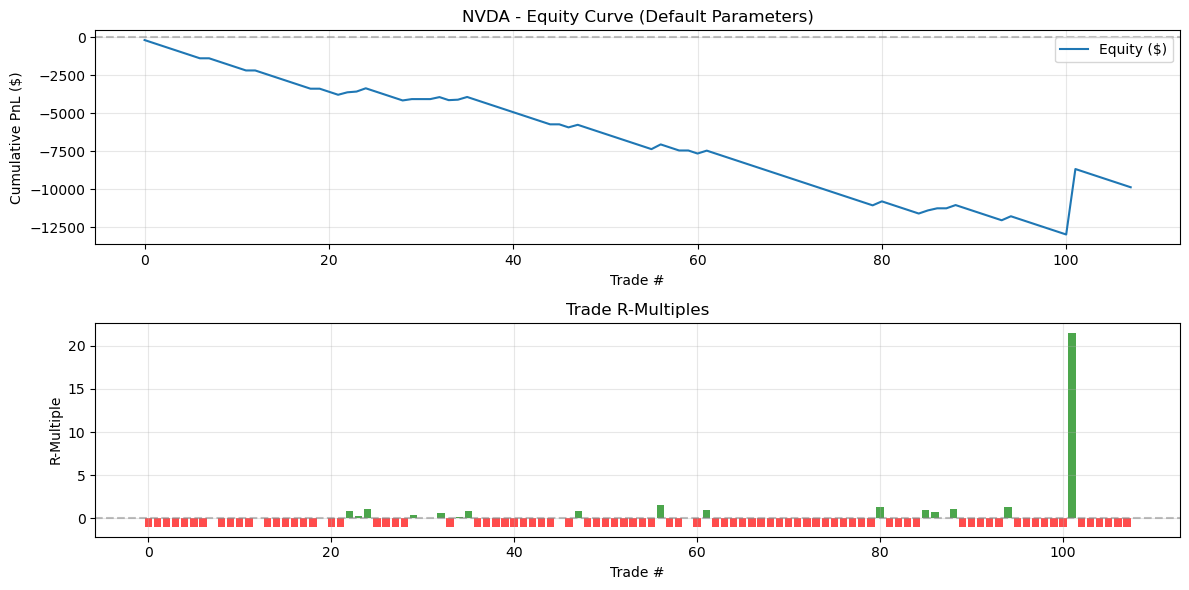

In [9]:
# Cell 7: Plot Equity Curve
if len(trades) > 0:
    plt.figure(figsize=(12, 6))
    
    equity = trades['pnl'].cumsum()
    plt.subplot(2, 1, 1)
    plt.plot(equity.values, label='Equity ($)')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.title(f'{symbol} - Equity Curve (Default Parameters)')
    plt.xlabel('Trade #')
    plt.ylabel('Cumulative PnL ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # R-multiples
    plt.subplot(2, 1, 2)
    colors = ['green' if r > 0 else 'red' for r in trades['pnl_r']]
    plt.bar(range(len(trades)), trades['pnl_r'], color=colors, alpha=0.7)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.title('Trade R-Multiples')
    plt.xlabel('Trade #')
    plt.ylabel('R-Multiple')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No trades to plot")

In [11]:
# Cell 8: Test Parameter Variation
print("=" * 50)
print("PARAMETER SENSITIVITY TEST")
print("=" * 50)

results = []
for min_conf in [2, 3, 4, 5]:
    test_config = ORBConfig(min_confluence_score=min_conf)
    test_trades = run_backtest(df, test_config, symbol=symbol)
    test_metrics = calculate_metrics(test_trades)
    
    results.append({
        'min_confluence': min_conf,
        'trades': test_metrics['total_trades'],
        'win_rate': f"{test_metrics['win_rate']:.1%}",
        'avg_r': f"{test_metrics['avg_r']:.2f}",
        'return_to_dd': f"{test_metrics['return_to_dd']:.2f}"
    })
    
results_df = pd.DataFrame(results)
display(results_df)

PARAMETER SENSITIVITY TEST


,min_confluence,trades,win_rate,avg_r,return_to_dd
0,2,159,13.8%,-0.47,-0.84
1,3,108,14.8%,-0.46,-0.77
2,4,83,13.3%,-0.43,-0.71
3,5,56,16.1%,-0.27,-0.48


## Next Steps

If this test works, we can proceed to:
1. Walk-forward validation framework
2. Optuna integration for parameter optimization
3. Multi-symbol testing

In [12]:
# Show first 5 trades with full details
trades[['entry_time', 'exit_time', 'direction', 'entry_price', 'exit_price', 'stop_price', 'exit_reason', 'pnl_r']].head(5)

,entry_time,exit_time,direction,entry_price,exit_price,stop_price,exit_reason,pnl_r
0,2025-10-29 09:59:00-04:00,2025-10-29 10:04:00-04:00,LONG,211.975,210.794543,210.794543,STOP_LOSS,-1.0
1,2025-10-30 09:35:00-04:00,2025-10-30 09:36:00-04:00,SHORT,202.355,202.365000,202.365000,STOP_LOSS,-1.0
2,2025-10-30 10:10:00-04:00,2025-10-30 10:11:00-04:00,SHORT,202.790,202.800000,202.800000,STOP_LOSS,-1.0
3,2025-10-30 10:17:00-04:00,2025-10-30 10:18:00-04:00,SHORT,202.605,202.615000,202.615000,STOP_LOSS,-1.0
4,2025-10-30 10:19:00-04:00,2025-10-30 10:20:00-04:00,SHORT,202.580,202.590000,202.590000,STOP_LOSS,-1.0
